## Assignment No.9

## Data Exploration & Missing Value Handling

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("adult_with_headers-1.csv")
df.columns = df.columns.str.strip()
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.describe())
print(df.isnull().sum())

df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

for col in ['workclass', 'occupation', 'native_country']:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())
print(df.shape)

(32561, 15)
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2   

# Standard Scaling

In [2]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
scaler_std = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[num_cols] = scaler_std.fit_transform(df[num_cols])
print(df_standard_scaled[num_cols].head())

        age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.030671 -1.063611       1.134739      0.148453      -0.21666   
1  0.837109 -1.008707       1.134739     -0.145920      -0.21666   
2 -0.042642  0.245079      -0.420060     -0.145920      -0.21666   
3  1.057047  0.425801      -1.197459     -0.145920      -0.21666   
4 -0.775768  1.408176       1.134739     -0.145920      -0.21666   

   hours_per_week  
0       -0.035429  
1       -2.222153  
2       -0.035429  
3       -0.035429  
4       -0.035429  


# Min-Max Scaling

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[num_cols] = scaler_minmax.fit_transform(df[num_cols])
print(df_minmax_scaled[num_cols].head())

        age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.301370  0.044302       0.800000       0.02174           0.0   
1  0.452055  0.048238       0.800000       0.00000           0.0   
2  0.287671  0.138113       0.533333       0.00000           0.0   
3  0.493151  0.151068       0.400000       0.00000           0.0   
4  0.150685  0.221488       0.800000       0.00000           0.0   

   hours_per_week  
0        0.397959  
1        0.122449  
2        0.397959  
3        0.397959  
4        0.397959  


# Data Exploration & Encoding Techniques

In [4]:
df = pd.read_csv("adult_with_headers-1.csv")
df.columns = df.columns.str.strip()
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))
df.replace('?', np.nan, inplace=True)

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe(include='all'))

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()[:5]}")

Shape: (32561, 15)

Data Types:
 age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

Missing Values:
 age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Summary Statistics:
                  age workclass        fnlwgt education  education_num  \
count   32561.000000     30725  3.256100e+04     32561   32561.000000   
unique           NaN         8    

# One-Hot Encoding

In [5]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns.tolist()
low_card = [col for col in cat_cols if df[col].nunique() < 5]
high_card = [col for col in cat_cols if df[col].nunique() >= 5]

print("One-Hot Encoding columns:", low_card)
print("Label Encoding columns:", high_card)

df_encoded = df.copy()
for col in ['workclass', 'occupation', 'native_country']:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].mode()[0])

df_encoded = pd.get_dummies(df_encoded, columns=low_card, drop_first=False)
print(df_encoded.shape)
print(df_encoded.head())

One-Hot Encoding columns: ['sex', 'income']
Label Encoding columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']
(32561, 17)
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race  capital_gain  \
0       Never-married       Adm-clerical  Not-in-family  White          2174   
1  Married-civ-spouse    Exec-managerial        Husband  White             0   
2            Divorced  Handlers-cleaners  Not-in-family  White             0   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black             0   
4  Married-civ-spouse     Prof-specialty      

# Label Encoding

In [6]:
le = LabelEncoder()
for col in high_card:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print(df_encoded[high_card].head())
print(df_encoded.dtypes)

   workclass  education  marital_status  occupation  relationship  race  \
0          6          9               4           0             1     4   
1          5          9               2           3             0     4   
2          3         11               0           5             1     4   
3          3          1               2           5             0     2   
4          3          9               2           9             5     2   

   native_country  
0              38  
1              38  
2              38  
3              38  
4               4  
age               int64
workclass         int64
fnlwgt            int64
education         int64
education_num     int64
marital_status    int64
occupation        int64
relationship      int64
race              int64
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country    int64
sex_Female         bool
sex_Male           bool
income_<=50K       bool
income_>50K        bool
dtype: object


# Creating 2 New Features

In [7]:
df = pd.read_csv("adult_with_headers-1.csv")
df.columns = df.columns.str.strip()
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))
df.replace('?', np.nan, inplace=True)

for col in ['workclass', 'occupation', 'native_country']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['net_capital'] = df['capital_gain'] - df['capital_loss']

education_order = {
    'Preschool': 1, '1st-4th': 2, '5th-6th': 3, '7th-8th': 4, '9th': 5,
    '10th': 6, '11th': 7, '12th': 8, 'HS-grad': 9, 'Some-college': 10,
    'Assoc-voc': 11, 'Assoc-acdm': 12, 'Bachelors': 13, 'Masters': 14,
    'Prof-school': 15, 'Doctorate': 16
}
df['education_level'] = df['education'].map(education_order)
df['age_education_interaction'] = df['age'] * df['education_level']

print(df[['age', 'education', 'education_level', 'capital_gain', 'capital_loss',
          'net_capital', 'age_education_interaction']].head(10))

   age  education  education_level  capital_gain  capital_loss  net_capital  \
0   39  Bachelors               13          2174             0         2174   
1   50  Bachelors               13             0             0            0   
2   38    HS-grad                9             0             0            0   
3   53       11th                7             0             0            0   
4   28  Bachelors               13             0             0            0   
5   37    Masters               14             0             0            0   
6   49        9th                5             0             0            0   
7   52    HS-grad                9             0             0            0   
8   31    Masters               14         14084             0        14084   
9   42  Bachelors               13          5178             0         5178   

   age_education_interaction  
0                        507  
1                        650  
2                        342  
3     

# Log Transformation on Skewed Feature

Skewness before transformation:
capital_gain    11.953848
capital_loss     4.594629
fnlwgt           1.446980
dtype: float64

Skewness after log transformation:
capital_gain_log    3.096144
capital_loss_log    4.307537
dtype: float64


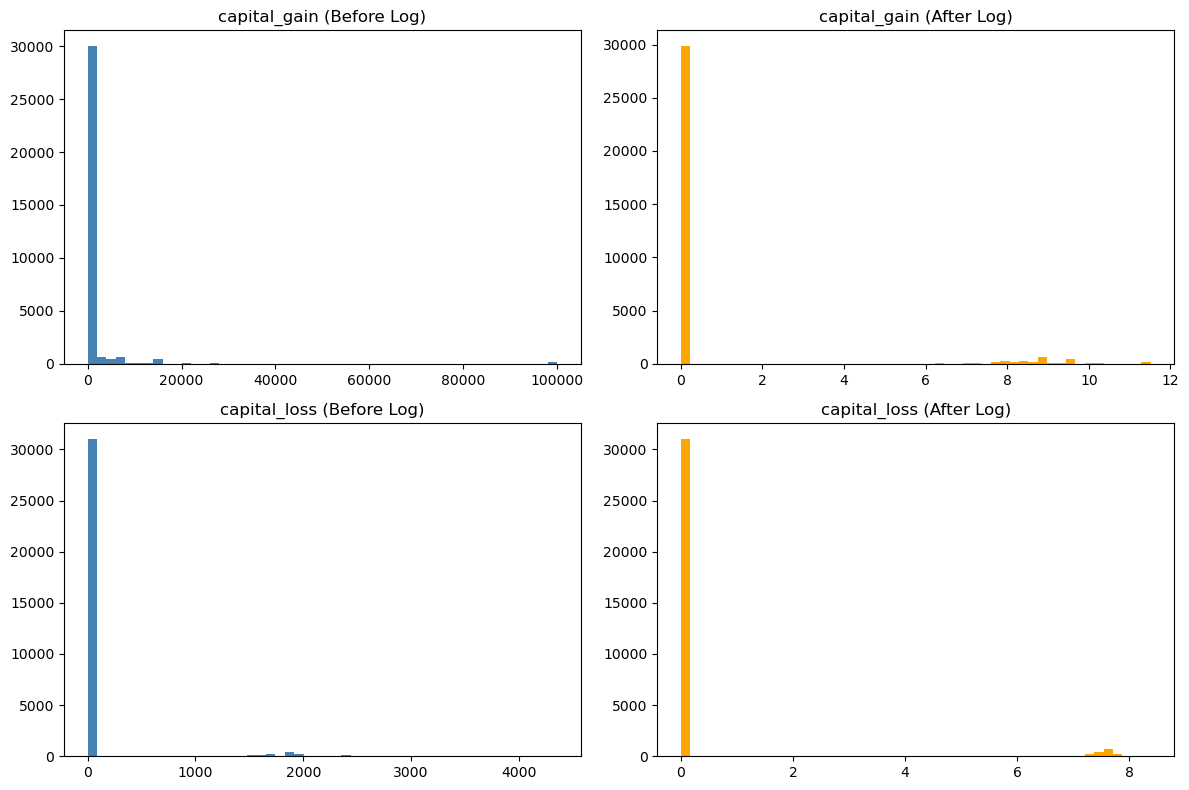

   capital_gain  capital_gain_log  capital_loss  capital_loss_log
0          2174          7.684784             0               0.0
1             0          0.000000             0               0.0
2             0          0.000000             0               0.0
3             0          0.000000             0               0.0
4             0          0.000000             0               0.0
5             0          0.000000             0               0.0
6             0          0.000000             0               0.0
7             0          0.000000             0               0.0
8         14084          9.552866             0               0.0
9          5178          8.552367             0               0.0


In [8]:
import matplotlib.pyplot as plt

print("Skewness before transformation:")
print(df[['capital_gain', 'capital_loss', 'fnlwgt']].skew())

df['capital_gain_log'] = np.log1p(df['capital_gain'])
df['capital_loss_log'] = np.log1p(df['capital_loss'])

print("\nSkewness after log transformation:")
print(df[['capital_gain_log', 'capital_loss_log']].skew())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(df['capital_gain'], bins=50, color='steelblue')
axes[0, 0].set_title('capital_gain (Before Log)')
axes[0, 1].hist(df['capital_gain_log'], bins=50, color='orange')
axes[0, 1].set_title('capital_gain (After Log)')
axes[1, 0].hist(df['capital_loss'], bins=50, color='steelblue')
axes[1, 0].set_title('capital_loss (Before Log)')
axes[1, 1].hist(df['capital_loss_log'], bins=50, color='orange')
axes[1, 1].set_title('capital_loss (After Log)')
plt.tight_layout()
plt.savefig('log_transformation.png')
plt.show()

print(df[['capital_gain', 'capital_gain_log', 'capital_loss', 'capital_loss_log']].head(10))